# **Collaborative Filtering With TensorFlow, ML1 Final Project, Group 2**

**Ellie Stewart, Junny Choi, and Payton Stewart**

## Model Description and Applications

Collaborative filtering (CF) is a recommendation approach that predicts what a user might like by analyzing how other users behave. For example, if two people have shown similar preferences in the past, they are likely to agree again in the future.

Instead of relying on item descriptions (like genre or category), collaborative filtering focuses on patterns in user behavior such as ratings, clicks, purchases, or views. These patterns are used to detect similarities between users or between items. Based on those similarities, the system recommends new items that similar users have already liked.

Collaborative filtering methods are divided into memory-based and model-based approaches. Memory-based methods make recommendations by directly comparing users or items using similarity measures. User-based filtering finds similar users, while item-based filtering finds similar items based on past interactions. Model-based methods instead learn patterns from the user–item data using machine learning techniques. A common example is matrix factorization, which represents users and items with lower-dimensional latent features to predict missing preferences more effectively.

According to IBM’s overview, collaborative filtering is widely adopted in recommendation systems because it remains effective even when data is limited, as long as sufficient user interaction data is available. It is commonly used in e-commerce, streaming services, social media, news platforms, and online advertising to personalize content and product suggestions based on patterns in user behavior.

Reference:
IBM. What is collaborative filtering?
https://www.ibm.com/think/topics/collaborative-filtering


## Key Components for Memory Based CF

**1. User Item Matrix**

Let the user item rating matrix be

$$
R \in \mathbb{R}^{m \times n}
$$

with observed entries indexed by

$$
\Omega \subseteq \{1,\dots,m\} \times \{1,\dots,n\}
$$


**2. Similarity Function**

Similarity between users or items is computed directly from observed ratings.

Cosine similarity

$$
sim(u,v) =
\frac{\sum_{i \in \Omega_u \cap \Omega_v} r_{ui} r_{vi}}
{\sqrt{\sum_{i \in \Omega_u} r_{ui}^2}
\sqrt{\sum_{i \in \Omega_v} r_{vi}^2}}
$$


Pearson correlation

$$
sim(u,v) =
\frac{\sum_{i \in \Omega_u \cap \Omega_v}(r_{ui}-\bar r_u)(r_{vi}-\bar r_v)}
{\sqrt{\sum_{i \in \Omega_u \cap \Omega_v}(r_{ui}-\bar r_u)^2}
\sqrt{\sum_{i \in \Omega_u \cap \Omega_v}(r_{vi}-\bar r_v)^2}}
$$ <br>


3. **Neighborhood Selection**

For a target user $u$, define the neighborhood $N(u)$ as the top $k$ most similar users who have rated item $i$.


4. **Prediction Function**

Using cosine similarity

$$
\hat r_{ui} =
\frac{\sum_{v \in N(u)} sim(u,v) r_{vi}}
{\sum_{v \in N(u)} |sim(u,v)|}
$$


Using Pearson correlation

$$
\hat r_{ui} =
\bar r_u +
\frac{\sum_{v \in N(u)} sim(u,v)(r_{vi}-\bar r_v)}
{\sum_{v \in N(u)} |sim(u,v)|}
$$

Memory based collaborative filtering computes predictions directly from similarity without learning latent parameters.

### Algorithm for Memory Based CF


Given $R$ and $\Omega$

1. Compute similarities  
For all user pairs $(u,v)$ compute $sim(u,v)$.

2. Select neighborhood  
For each target $(u,i)$ construct $N(u)$ as the top $k$ similar users who rated item $i$.

3. Predict ratings  
Compute

$$
\hat r_{ui} =
\frac{\sum_{v \in N(u)} sim(u,v) r_{vi}}
{\sum_{v \in N(u)} |sim(u,v)|}
$$

4. Output  
The predicted rating $\hat r_{ui}$ is used to rank items and recommend the highest scoring items.

## Key Components for Model Based

1. **User Rating Matrix**

Let the rating matrix be

$$
R \in \mathbb{R}^{m \times n}
$$

with observed entries indexed by Ω

2. **Latent Factor Representation**

Each user and item is represented in a shared $k$ dimensional latent space.

User latent vector

$$
u_u \in \mathbb{R}^k
$$

Item latent vector

$$
v_i \in \mathbb{R}^k
$$

Stacked matrices

$$
U \in \mathbb{R}^{m \times k}, \quad V \in \mathbb{R}^{n \times k}
$$

Low rank approximation

$$
R \approx U V^T
$$


3. **Prediction Function**

$$
\hat r_{ui} = u_u^T v_i
$$

With bias terms

$$
\hat r_{ui} = \mu + b_u + b_i + u_u^T v_i
$$


4. **Objective Function**

$$
\min_{U,V}
\sum_{(u,i)\in\Omega}
(r_{ui} - u_u^T v_i)^2
+
\lambda (||U||_F^2 + ||V||_F^2)
$$

### Algorithm for Model Based CF

Given $R$ and $\Omega$, train a regularized matrix factorization model with SGD (stochastic gradient descent):

1. **Initialize parameters**

Initialize $U$ and $V$ with small random values.

2. **Minimize objective**

Solve

$$
\min_{U,V}
\sum_{(u,i)\in\Omega}
(r_{ui} - u_u^T v_i)^2
+
\lambda (||U||_F^2 + ||V||_F^2)
$$

3. **Optimization (SGD example)**

For each observed entry $(u,i)\in\Omega$

$$
e_{ui} = r_{ui} - u_u^T v_i
$$

$$
u_u \leftarrow u_u + \eta (e_{ui} v_i - \lambda u_u)
$$

$$
v_i \leftarrow v_i + \eta (e_{ui} u_u - \lambda v_i)
$$

where $\eta$ is the learning rate and $\lambda$ is the regularization strength.

4. **Output**  

After training, predict with

$$
\hat r_{ui} = u_u^T v_i
$$

and recommend items with the highest predicted scores.

## Available Packages

There are several packages available for collaborative filtering. Surprise provides built-in implementations of kNN and SVD for traditional memory-based and matrix factorization methods. The implicit library focuses on large-scale recommendation with implicit feedback using algorithms like ALS and BPR. LightFM supports hybrid models that combine collaborative filtering with content features. More flexible frameworks like TensorFlow or PyTorch allow custom and neural network–based recommendation models.

For this project, we chose TensorFlow because it gives us more control over how the model is built. It allows us to implement matrix factorization, and it scales well for larger datasets. It also makes it easier to extend the model later if we want to experiment with additional features. **ELABORATE**

## Basic Example (User - Movie Ratings)

For a basic example, we will simulate a movie recommendation system using model based collaborative filtering. We first generate a synthetic dataset where 29 users rate 100 movies on a scale from 1 to 5 and treat this complete matrix as the ground truth. To mimic real world recommendation data, we randomly remove about 60 percent of the ratings to create an observed matrix with missing values. We then convert the observed ratings into user movie rating pairs and train a matrix factorization model in TensorFlow, where each user and movie is represented by a latent embedding along with bias terms, and the model learns to predict ratings by minimizing squared error with regularization. After training, we reconstruct the full predicted rating matrix, evaluate the model by comparing predictions to the hidden ground truth ratings using RMSE and MAE, and finally generate top movie recommendations for a few selected users while also showing the true ratings for those recommended movies.

In [30]:
import numpy as np
import pandas as pd
import tensorflow as tf

# Set seed so results are reproducible
seed = 31017
np.random.seed(seed)
tf.random.set_seed(seed)

# Define users (29)
users = [
"Junny","Ellie","Payton","Francisco","Alice","Bob","Carol","Dave","Eve","Frank",
"Grace","Henry","Ivy","Jack","Karen","Leo","Maya","Nina","Oscar","Paul",
"Quinn","Rita","Sam","Tina","Uma","Victor","Wendy","Xavier","Yara"
]

# Define movies (100)
movies = [
"Titanic","Avatar","Batman","Toy Story","Inception","Matrix","Interstellar",
"Frozen","Joker","Avengers","Spider-Man","The Dark Knight","La La Land",
"Jurassic Park","Star Wars","Harry Potter","Lord of the Rings","Shrek",
"Gladiator","Top Gun","Iron Man","Thor","Black Panther","Captain Marvel",
"Guardians of the Galaxy","Doctor Strange","Ant-Man","Deadpool",
"Wonder Woman","Aquaman","The Flash","Superman","Minions","Cars",
"Finding Nemo","Inside Out","Up","Coco","Ratatouille","Monsters Inc",
"Kung Fu Panda","Madagascar","Ice Age","How to Train Your Dragon",
"The Lion King","Aladdin","Beauty and the Beast","Mulan","Tangled","Moana",

"The Godfather","Pulp Fiction","Forrest Gump","The Shawshank Redemption",
"The Social Network","Fight Club","The Departed","The Prestige",
"Whiplash","Parasite","No Country for Old Men","Dune",
"Mission Impossible","The Bourne Identity","Mad Max Fury Road",
"Skyfall","Casino Royale","John Wick","The Hunger Games",
"The Maze Runner","The Incredibles","Big Hero 6","Encanto",
"Luca","Turning Red","Brave","Soul",
"A Quiet Place","Get Out","Us","The Conjuring",
"It","The Ring","The Exorcist","Hereditary",
"Mean Girls","Clueless","Legally Blonde","The Devil Wears Prada",
"Notting Hill","Love Actually","Pretty Woman","The Notebook",
"Ocean's Eleven","Catch Me If You Can","The Wolf of Wall Street",
"The Big Short","Moneyball","The Truman Show"
]

num_users = len(users)
num_movies = len(movies)

# Create full rating matrix with integer ratings (1-5)
ground_truth = np.random.randint(1, 6, size=(num_users, num_movies))

ground_truth_df = pd.DataFrame(
    ground_truth,
    index=users,
    columns=movies
)

# Copy matrix and convert to float so NaN can exist
observed_df = ground_truth_df.astype(float)

# Randomly remove ratings
drop_rate = 0.6
drop_mask = np.random.rand(num_users, num_movies) < drop_rate
observed_df.values[drop_mask] = np.nan

# Store matrices
R_true = ground_truth_df.values
R_obs = observed_df.values

# Show preview
preview_movies = movies[:8]

print("Ground Truth Ratings")
display(ground_truth_df.loc[:, preview_movies].head(4))

print("Observed Ratings with Missing Values")
display(observed_df.loc[:, preview_movies].head(4))

Ground Truth Ratings


,Titanic,Avatar,Batman,Toy Story,Inception,Matrix,Interstellar,Frozen
Junny,3,3,5,5,4,4,5,3
Ellie,5,5,4,5,4,1,3,2
Payton,5,4,3,4,5,1,2,5
Francisco,2,3,3,3,1,4,5,5


Observed Ratings with Missing Values


,Titanic,Avatar,Batman,Toy Story,Inception,Matrix,Interstellar,Frozen
Junny,3.0,NaN,5.0,NaN,NaN,NaN,NaN,3.0
Ellie,5.0,5.0,NaN,NaN,4.0,1.0,3.0,NaN
Payton,5.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN
Francisco,NaN,3.0,3.0,3.0,NaN,NaN,5.0,5.0


In [31]:
# Identify all user–movie pairs with ratings and extract their rating values
obs_u, obs_i = np.where(~np.isnan(R_obs))
obs_r = R_obs[obs_u, obs_i]

# Convert the extracted data into TensorFlow tensors for model training
u_ids = tf.constant(obs_u, dtype=tf.int32)
i_ids = tf.constant(obs_i, dtype=tf.int32)
ratings = tf.constant(obs_r, dtype=tf.float32)

# Latent dimension for embeddings:
# A higher value gives the model more hidden features to represent user preferences
# and movie characteristics, allowing it to capture more complex patterns.
# A lower value creates a simpler model that trains faster but may miss important relationships.
k = 8

# Global mean rating (should be around 3, since ratings are 1-5)
mu = tf.Variable(tf.reduce_mean(ratings), dtype=tf.float32)

# User and movie latent factor matrices
U = tf.Variable(tf.random.normal([num_users, k], stddev=0.05))
V = tf.Variable(tf.random.normal([num_movies, k], stddev=0.05))

# Bias terms for users and movies:
# User bias captures how a user tends to rate items overall
# (for example, some users consistently give higher or lower ratings).
# Movie bias captures how a movie tends to be rated across all users
# (for example, some movies are generally liked more than others).
b_u = tf.Variable(tf.zeros([num_users]))
b_i = tf.Variable(tf.zeros([num_movies]))

# Prediction function for user–movie pairs
def predict(u, i):
    u_vec = tf.gather(U, u)
    i_vec = tf.gather(V, i)

    return (
        mu
        + tf.gather(b_u, u)
        + tf.gather(b_i, i)
        + tf.reduce_sum(u_vec * i_vec, axis=1)
    )

# Learning rate:
# A higher learning rate updates parameters more quickly but can make training unstable.
# A lower learning rate results in slower but more stable learning.
optimizer = tf.keras.optimizers.Adam(0.01)

# Regularization:
# A higher value penalizes large parameter values more strongly,
# keeping predictions closer to the global mean and reducing overfitting.
# A lower value allows the model to fit the data more aggressively,
# which can produce more extreme predictions but may overfit the training data.
reg = 0.005

# Number of training epochs:
# More epochs allow the model to learn patterns more thoroughly but increase training time.
# Fewer epochs reduce training time but may stop the model before it fully learns the data.
for epoch in range(1500):

    with tf.GradientTape() as tape:

        pred = predict(u_ids, i_ids)
        mse = tf.reduce_mean((ratings - pred) ** 2)

        l2 = (
            tf.reduce_sum(U**2)
            + tf.reduce_sum(V**2)
            + tf.reduce_sum(b_u**2)
            + tf.reduce_sum(b_i**2)
        )

        loss = mse + reg * l2

    grads = tape.gradient(loss, [U, V, b_u, b_i, mu])
    optimizer.apply_gradients(zip(grads, [U, V, b_u, b_i, mu]))

    if epoch % 200 == 0:
        print(epoch, mse.numpy())

# Reconstruct the full predicted rating matrix
R_pred = (
    mu.numpy()
    + b_u.numpy()[:, None]
    + b_i.numpy()[None, :]
    + np.dot(U.numpy(), V.numpy().T)
)

# Keep predictions within the rating scale
R_pred = np.clip(R_pred, 1, 5)

pred_df = pd.DataFrame(np.round(R_pred, 2), index=users, columns=movies)

# Evaluate predictions on ratings that were hidden during training
heldout_mask = np.isnan(R_obs)

true_heldout = R_true[heldout_mask]
pred_heldout = R_pred[heldout_mask]

rmse = np.sqrt(np.mean((true_heldout - pred_heldout) ** 2))
mae = np.mean(np.abs(true_heldout - pred_heldout))

print("Evaluation on hidden ratings")
print(f"RMSE: {rmse:.3f}")
print(f"MAE:  {mae:.3f}")

# Show sample comparisons of predicted vs true ratings
heldout_u, heldout_i = np.where(heldout_mask)

sample_idx = np.random.choice(len(heldout_u), 10, replace=False)

comparison_df = pd.DataFrame({
    "User":[users[heldout_u[i]] for i in sample_idx],
    "Movie":[movies[heldout_i[i]] for i in sample_idx],
    "True Rating":[R_true[heldout_u[i], heldout_i[i]] for i in sample_idx],
    "Predicted":[np.round(R_pred[heldout_u[i], heldout_i[i]],2) for i in sample_idx]
})

comparison_df

0 2.05179
200 0.79146975
400 0.7834237
600 0.78348225
800 0.7834896
1000 0.783488
1200 0.78349274
1400 0.7834902
Evaluation on hidden ratings
RMSE: 1.530
MAE:  1.306


,User,Movie,True Rating,Predicted
0,Ivy,Avengers,3,3.16
1,Yara,Love Actually,2,2.97
2,Tina,The Dark Knight,3,3.68
3,Bob,Tangled,2,3.65
4,Maya,Moana,1,1.98
5,Wendy,Iron Man,5,2.93
6,Karen,Deadpool,2,2.56
7,Nina,No Country for Old Men,1,2.86
8,Xavier,Minions,3,2.75
9,Frank,Mad Max Fury Road,3,3.72


The model gets an RMSE of about 1.53 and an MAE of about 1.31, meaning predictions are typically around 1 to 1.5 rating points away from the true value on a 1 to 5 scale, which is relatively large. Although this data is synthetic, we could improve the model by tuning model parameters such as increasing the latent dimension, adjusting regularization, or training for more epochs so the model can capture more variation in the ratings.

In [32]:
# Generate recommendations for selected users
selected_users = ["Junny","Ellie","Payton","Francisco"]

for user in selected_users:

    user_id = users.index(user)

    # Identify movies the user did not rate
    unrated = np.where(np.isnan(R_obs[user_id]))[0]
    scores = R_pred[user_id, unrated]

    # Rank movies by predicted rating
    recommendations = sorted(
        [(movies[i], scores[j], R_true[user_id, i]) for j, i in enumerate(unrated)],
        key=lambda x: -x[1]
    )

    print(f"\nTop 3 movie recommendations for {user}")

    for movie, pred_score, true_score in recommendations[:3]:
        print(f"{movie:25} predicted: {pred_score:.2f} | true rating: {true_score}")


Top 3 movie recommendations for Junny
Clueless                  predicted: 4.38 | true rating: 5
Get Out                   predicted: 4.06 | true rating: 5
Iron Man                  predicted: 4.02 | true rating: 2

Top 3 movie recommendations for Ellie
The Flash                 predicted: 3.95 | true rating: 5
Guardians of the Galaxy   predicted: 3.88 | true rating: 1
Big Hero 6                predicted: 3.88 | true rating: 1

Top 3 movie recommendations for Payton
Interstellar              predicted: 3.67 | true rating: 2
Inside Out                predicted: 3.59 | true rating: 5
Up                        predicted: 3.59 | true rating: 2

Top 3 movie recommendations for Francisco
Titanic                   predicted: 4.17 | true rating: 2
Madagascar                predicted: 3.96 | true rating: 4
Notting Hill              predicted: 3.90 | true rating: 1


We can see that at least one of the top three recommended movies for each user has a ground truth rating of 4 or higher. This suggests that the user would likely enjoy at least one of the three movies recommended by the model.

## Real-World Application

### **Objective** <br>
The overall aim of this application is to uncover latent structural patterns correlated with violence across African countries and to evaluate whether matrix factorization methods—adapted from collaborative filtering in recommender systems—can improve short-term forecasting of conflict frequency. Rather than modeling each country independently, this approach treats violence as a structured cross-national system driven by shared but unobserved regional dynamics. Using collaborative filtering, if possible, we hope to uncover latent conflict regimes and quantify structural similarity across African countries. The final goal is to see if these latent factors enhance predictive performance relative to traditional time-series baselines. <br>
Using Africa is a conscious choice. We understand the way many national boarders were drawn (through European imperialism) intuitively would contribute to conflicts having spillover effects, which could be an important aspect of the cross-national system similarity found in this exercise. Spillover effects have also been proven in earlier literature through a natural resource mechanism. See ["This Mine Is Mine! How Minerals Fuel Conflict In Africa"](https://www.aeaweb.org/articles?id=10.1257/aer.20150774). Africa also provides an ideal context because 1) the data is available and 2) conflict dynamics exhibit: insurgency waves, coups and regime instability, and regional contagion effects. This goes beyond spillovers. We choose just one region because it reduces heterogeneity relative to a global dataset.

### **Dataset Description** <br>
The analysis uses aggregated country–week data for Africa, current as of Feb 14, 2026, from the Armed Conflict Location & Event Data Project (ACLED). It can be found [here](https://acleddata.com/aggregated/aggregated-data-africa). <br> The original dataset contains over 265,000 observations of the number of  events per country per week across African states. All states in continental Africa except South Sudan have data going back to Jan 1997. South Sudan coverage begins in Jan 2011. The rest of the columns we deem of note are EVENT_TYPE, SUB_EVENT_TYPE, EVENTS, FATALITIES, CENTROID_LATITUDE, and CENTROID_LONGITUDE. According to ACLED's codebook, event types included in this dataset are battles, protests, riots, explosions/remote violence, violence against civilians, and strategic developments. Definitions of each are as follows: <br>
<br>
**Battles:**  a violent interaction between two organized armed groups at a particular time and location. Battles can occur between armed and organized state, non-state, and external groups, and in any combination thereof. There is no fatality minimum necessary for inclusion. <br>
<br>
**Protests:** an in-person public demonstration of three or more participants in which the participants do not engage in violence, though violence may be used against them. Events include individuals and groups who peacefully demonstrate against a political entity, government institution, policy, group, tradition, business, or other private institution. The following are not recorded as Protests events: symbolic public acts such as displays of flags or public prayers (unless they are accompanied by a demonstration); legislative protests, such as parliamentary walkouts or members of parliaments staying silent; strikes (unless they are accompanied by a demonstration); and individual acts such as self-harm actions like individual immolations or hunger strikes. <br>
<br>
**Riots:** violent events where demonstrators or mobs of three or more engage in violent or destructive acts, including but not limited to physical fights, rock throwing, property destruction, etc. They may engage individuals, property, businesses, other rioting groups, or armed actors. <br> <br>
**Explosions/Remote Violence:** incidents in which one side uses weapon types that, by their nature, are at range and widely destructive. The weapons used in Explosions/Remote violence events are explosive devices, including but not limited to: bombs, grenades, IEDs, artillery fire or shelling, missile attacks, air or drone strikes, and other widely destructive heavy weapons or chemical weapons. Suicide attacks using explosives also fall under this category. When an ‘Explosions/Remote violence event is reported in the context of an ongoing battle, it is merged and recorded as a single Battles event. <br> <br>
**Violence Against Civilians:** violent events where an organized armed group inflicts violence upon unarmed non-combatants. By definition, civilians are unarmed and cannot engage in political violence. Therefore, the violence is understood to be asymmetric as the perpetrator is assumed to be the only actor capable of using violence in the event. The perpetrators of such acts include state forces and their affiliates, rebels, militias, and external/other forces. <br> <br>
**Strategic Developments:** This event type captures contextually important information regarding incidents and activities of groups that are not recorded as Political violence or Demonstrations events, yet may trigger future events or contribute to political dynamics within and across states. The inclusion of such events is limited, as their purpose is to capture pivotal events within the broader political landscape. They typically include a disparate range of events, such as recruitment drives, looting, and incursions, as well as the location and date of peace talks and the arrests of high-ranking officials or large groups. <br> <br> <br>

Each event type has sub event types that we could have honed in on for severity, but the above is clearly hierarchial, which is very necessary for collaborative filtering because we need the data to be ordinal. So we sacrifice granularity for accuracy. Further descriptions can again be found at ACLED.

### **Load and Clean Data**

In [33]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

file_path = '/content/drive/MyDrive/Africa_aggregated_data_up_to-2026-02-14.xlsx'

df = pd.read_excel(file_path)

print(df.info())
display(df.head())

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265548 entries, 0 to 265547
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   WEEK                 265548 non-null  datetime64[ns]
 1   REGION               265548 non-null  object        
 2   COUNTRY              265548 non-null  object        
 3   ADMIN1               265548 non-null  object        
 4   EVENT_TYPE           265548 non-null  object        
 5   SUB_EVENT_TYPE       265548 non-null  object        
 6   EVENTS               265548 non-null  int64         
 7   FATALITIES           265548 non-null  int64         
 8   POPULATION_EXPOSURE  170127 non-null  float64       
 9   DISORDER_TYPE        265548 non-null  object        
 10  ID                   265543 non-null  float64       
 11  CENTROID_LATITUDE    265548 non-null  float64       
 12  CENTROID_LONGITUDE   265548 non-null  float64 

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE
0,2004-10-23,Northern Africa,Algeria,Adrar,Battles,Armed clash,1,2,NaN,Political violence,47.0,26.4839,-1.388
1,2005-04-23,Northern Africa,Algeria,Adrar,Battles,Armed clash,1,0,NaN,Political violence,47.0,26.4839,-1.388
2,2005-06-25,Northern Africa,Algeria,Adrar,Battles,Armed clash,1,14,NaN,Political violence,47.0,26.4839,-1.388
3,2008-12-13,Northern Africa,Algeria,Adrar,Battles,Armed clash,1,3,NaN,Political violence,47.0,26.4839,-1.388
4,2009-04-18,Northern Africa,Algeria,Adrar,Battles,Armed clash,1,2,NaN,Political violence,47.0,26.4839,-1.388


**Severity Matrix Construction**

**Fill in empty cells:** <br>
- If an event was recorded but the event_type is blank or not in the list it is assigned 1 (Strategic Development) because something happened, but it wasn't a violent war. This is an assumption that could impact results.
- If there's nothing that week for a country, it is a "Peaceful Week". We add the week to the data and add a 0 because this is still observed information relevant to the latent state.

In [34]:
# Map events
severity_map = {
    'Strategic developments': 1,
    'Protests': 2,
    'Riots': 3,
    'Violence against civilians': 4,
    'Explosions/Remote violence': 5,
    'Battles': 6
}
df['severity_score'] = df['EVENT_TYPE'].map(severity_map).fillna(1)

In [35]:
# Aggregate counts and find the max severity reached in that week
aggr_df = df.groupby(['COUNTRY', 'REGION', 'WEEK']).agg(
    weekly_events=('EVENTS', 'sum'),
    max_severity=('severity_score', 'max'),
    total_fatalities=('FATALITIES', 'sum')
).reset_index()

# Sort by country and time to ensure lags are calculated correctly
aggr_df = aggr_df.sort_values(['COUNTRY', 'WEEK'])

Our collaborative filtering model won't stand alone. Recalling the main goal being to forecast conflict, we need to feature engineer some lagged indicators, one being if severity escalated.

In [36]:
# 1. Indicator: Was there conflict in the previous week?
# We check if the 'weekly_events' from the previous row for the SAME country is > 0
aggr_df['prev_week_events'] = aggr_df.groupby('COUNTRY')['weekly_events'].shift(1).fillna(0)
aggr_df['has_prior_conflict'] = (aggr_df['prev_week_events'] > 0).astype(int)

# 2. Indicator: Did conflict escalate?
# Compare current max severity to previous max severity
aggr_df['prev_severity'] = aggr_df.groupby('COUNTRY')['max_severity'].shift(1).fillna(0)
aggr_df['is_escalated'] = (aggr_df['max_severity'] > aggr_df['prev_severity']).astype(int)

# 3. Categorical Indicators for TensorFlow (Country and Region)
aggr_df['country_code'] = aggr_df['COUNTRY'].astype('category').cat.codes
aggr_df['region_code'] = aggr_df['REGION'].astype('category').cat.codes

In [37]:
# Create a complete grid of all countries and all weeks
all_weeks = aggr_df['WEEK'].unique()
all_countries = aggr_df['COUNTRY'].unique()
grid = pd.MultiIndex.from_product([all_countries, all_weeks], names=['COUNTRY', 'WEEK']).to_frame(index=False)

# Merge our aggregated data back onto this grid
final_df = pd.merge(grid, aggr_df, on=['COUNTRY', 'WEEK'], how='left').fillna(0)

In [38]:
final_df["prev_week_events"] = (
    final_df
    .groupby("COUNTRY")["weekly_events"]
    .shift(1)
)

The above captures the most severe state of each country in each week and disregards less severe observations.

**Check Cleaning**

In [39]:
raw_total = df['EVENTS'].sum()
clean_total = final_df['weekly_events'].sum()

print(f"Original Events: {raw_total}")
print(f"Aggregated Events: {clean_total}")

if raw_total == clean_total:
    print("No events were lost during aggregation.")
else:
    print("Sums do not match.")

Original Events: 475008
Aggregated Events: 475008.0
No events were lost during aggregation.


In [40]:
test_country = all_countries[0] # This picks the first country in the dataset (e.g., Algeria)
country_data = final_df[final_df['COUNTRY'] == test_country]

print(f"Checking data for: {test_country}")
check_cols = ['WEEK', 'weekly_events', 'max_severity', 'prev_severity', 'is_escalated', 'has_prior_conflict']
display(country_data[check_cols].head(15))

Checking data for: Algeria


,WEEK,weekly_events,max_severity,prev_severity,is_escalated,has_prior_conflict
0,1996-12-28,3.0,4.0,0.0,1.0,0.0
1,1997-01-04,9.0,6.0,4.0,1.0,1.0
2,1997-01-11,10.0,6.0,6.0,0.0,1.0
3,1997-01-18,13.0,6.0,6.0,0.0,1.0
4,1997-01-25,7.0,6.0,6.0,0.0,1.0
5,1997-02-01,3.0,4.0,6.0,0.0,1.0
6,1997-02-08,1.0,4.0,4.0,0.0,1.0
7,1997-02-15,1.0,4.0,4.0,0.0,1.0
8,1997-02-22,3.0,4.0,4.0,0.0,1.0
9,1997-03-29,3.0,4.0,4.0,0.0,1.0


In [41]:
# Check for sparsity
sparsity = (final_df['weekly_events'] == 0).mean()
print(f"Matrix Sparsity: {sparsity:.2%}")

Matrix Sparsity: 56.70%


Half of the observations now are countries where the state was "Peaceful" during the week observed.

**Prepare for TensorFlow by creating integer indices**

In [42]:
# 1. Create unique mapping for Countries and Weeks
final_df['country_id'] = final_df['COUNTRY'].astype('category').cat.codes
final_df['week_id'] = final_df['WEEK'].astype('category').cat.codes

# Replace 0 with NaN first
final_df["REGION"] = final_df["REGION"].replace(0, pd.NA)
final_df["region_code"] = final_df["region_code"].replace(0, pd.NA)

# Fill within each country
final_df["REGION"] = (
    final_df.groupby("COUNTRY")["REGION"]
    .transform(lambda x: x.ffill().bfill())
)

final_df["region_code"] = (
    final_df.groupby("COUNTRY")["region_code"]
    .transform(lambda x: x.ffill().bfill())
)

# 2. Extract the total counts for the Embedding layers
num_countries = final_df['country_id'].nunique()
num_weeks = final_df['week_id'].nunique()

print(f"Ready for TensorFlow:")
print(f"- Unique Countries (Rows): {num_countries}")
print(f"- Unique Weeks (Columns): {num_weeks}")
print(f"- Total Training Samples: {len(final_df)}")

# 3. Save this to a CSV
final_df.to_csv(
    '/content/drive/MyDrive/Africa_Conflict_Cleaned_ML_Ready.csv',
    index=False
)

Ready for TensorFlow:
- Unique Countries (Rows): 58
- Unique Weeks (Columns): 1521
- Total Training Samples: 88218


/tmp/ipykernel_383/1209379172.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill().bfill())


### **EDA**

In [43]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Africa_Conflict_Cleaned_ML_Ready.csv'

final_df = pd.read_csv(file_path)
final_df = final_df.dropna(subset=["prev_week_events"])
print(final_df.info())
display(final_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
Index: 88160 entries, 1 to 88217
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   COUNTRY             88160 non-null  object 
 1   WEEK                88160 non-null  object 
 2   REGION              88160 non-null  object 
 3   weekly_events       88160 non-null  float64
 4   max_severity        88160 non-null  float64
 5   total_fatalities    88160 non-null  float64
 6   prev_week_events    88160 non-null  float64
 7   has_prior_conflict  88160 non-null  float64
 8   prev_severity       88160 non-null  float64
 9   is_escalated        88160 non-null  float64
 10  country_code        88160 non-null  float64
 11  region_code         59280 non-null  float64
 12  country_id          88160 non-null  int64  
 13  week_id             88160 n

,COUNTRY,WEEK,REGION,weekly_events,max_severity,total_fatalities,prev_week_events,has_prior_conflict,prev_severity,is_escalated,country_code,region_code,country_id,week_id
1,Algeria,1997-01-04,Northern Africa,9.0,6.0,90.0,3.0,1.0,4.0,1.0,0.0,2.0,0,1
2,Algeria,1997-01-11,Northern Africa,10.0,6.0,89.0,9.0,1.0,6.0,0.0,0.0,2.0,0,2
3,Algeria,1997-01-18,Northern Africa,13.0,6.0,226.0,10.0,1.0,6.0,0.0,0.0,2.0,0,3
4,Algeria,1997-01-25,Northern Africa,7.0,6.0,51.0,13.0,1.0,6.0,0.0,0.0,2.0,0,4
5,Algeria,1997-02-01,Northern Africa,3.0,4.0,44.0,7.0,1.0,6.0,0.0,0.0,2.0,0,5


In [44]:
final_df.describe()

,weekly_events,max_severity,total_fatalities,prev_week_events,has_prior_conflict,prev_severity,is_escalated,country_code,region_code,country_id,week_id
count,88160.000000,88160.000000,88160.000000,88160.000000,88160.000000,88160.000000,88160.000000,88160.000000,59280.000000,88160.000000,88160.000000
mean,5.387716,1.941447,12.351055,5.387409,0.432668,1.939553,0.093001,12.879537,2.794872,28.500000,760.500000
std,15.224889,2.461735,135.161692,15.224785,0.495448,2.461535,0.290436,18.677258,1.202134,16.740764,438.788598
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,14.000000,380.750000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,28.500000,760.500000
75%,3.000000,4.000000,1.000000,3.000000,1.000000,4.000000,0.000000,26.000000,4.000000,43.000000,1140.250000
max,234.000000,6.000000,19663.000000,234.000000,1.000000,6.000000,1.000000,57.000000,4.000000,57.000000,1520.000000


### **The Model: Poisson Matrix Factorization with Bias and Temporal Autoregression**

While conflict intensity is important, we choose to model conflict frequency or weekly_events because there is more variation here. The model then becomes: <br>

$$Y_{c,t} : Poisson(λ_{c,t})$$ <br>
$$log(λ_{c,t}​)=μ+b_c​+b_t​+U_c^⊤*​V_t​+αlog(1+ Y_{c,t−1})​$$ <br> <br>


*   Y: The weekly event count (for country, c in time t).
*   λ: The expected mean of the weekly event distribution (for country c in time t). Logged in the model to keep predictions for conflict greater than or equal to 0.
*   μ: Global intercept or the baseline for conflict in Africa. Assumed constant.
*   b: The baseline fixed effects. We have one per each country and one for each week. These adjust the global intercept, and it prevents the embeddings from wasting capacity on obvious baseline differences between countries or time trends. The weekly baseline can capture global shocks that effect all countries, mathematically is absorbs the mean count of violence that week.
*   αlog(1+Y): The previous week's event count for country c logged. So t-1. Works better because of high variation.
*  **U_c^⊤​V_t: The collaborative filtering engine. Elaborated on below.** <br>






**Collaborative Filtering Component** <br>
$$X \approx U_c^⊤*​V_t$$ <br>

X: The full rank matrix of country by week with weekly event observations as the entries. We want to approximate this with the low-rank right side of the above. <br>
U: matrix of stacked country embeddings. Each country embedding is composed of the K latent factors discovered by the algorithm. Conceptually, this is things intrinsic to the country, like it's susceptability to spillovers or government instability, that we won't know but determine the position of that country in space.<br>
V: matrix of stacked week embeddings. Each week embedding is also composed of K latent factors. Conceptually this is a conflict regime for each time. It may be based on factors are likely seasonal but again, unobserved. One example could be a bunch of states holding elections in the same week and this happens every year. t and t+52 would likely be similar here. <br>
K: embedding dimension (small, like 5). Number of latent factors. <br> <br>

We partially predict violence with these embeddings and then add them to the baselines for each. Collaborative filtering allows us to capture a structural belief about Africa. That belief is that countries do not behave independently. They share violence trajectories based on some latent factors captured by this part of the model. A dot product near 0 will predict baseline conflict counts, negtive will be less than baseline, and positive will be well above baseline.

**Analog** <br>
An easy analog here is the Netflix recommendation engine. <br>
There movie suggestions are based on user's interactions and previous ratings on movies. If Alice is deemed a similar user to Bob, then a movie Alice hasn't watched that Bob rated highly, might be suggested for Alice. Here the users are our countries in Africa, the movies watched are the weeks observed, and the ratings are the weekly event counts.

**Building the Model in Tensorflow**

We will use a custom Keras Model. Instead of a standard dot product, we’ll use Embedding layers to represent countries ($u_c$) and months ($v_t$). We will also employ l2 regularization and poisson likelihood, which is a built-in in Tensorflow. For train/test, we will be sure to prevent information leakage.

In [45]:
# map countries to ids once
country_lookup = (
    final_df[["country_id", "COUNTRY"]]
    .drop_duplicates()
    .sort_values("country_id")
    .reset_index(drop=True)
)

In [46]:
# Split for train/test respecting time series. Scaling is not necessary
import numpy as np
final_df = final_df.sort_values("week_id")

unique_weeks = np.sort(final_df["week_id"].unique())

train_frac = 0.8
cutoff_index = int(len(unique_weeks) * train_frac)

train_weeks = unique_weeks[:cutoff_index]
test_weeks = unique_weeks[cutoff_index:]

train_df = final_df[final_df["week_id"].isin(train_weeks)].copy()
test_df = final_df[final_df["week_id"].isin(test_weeks)].copy()

print("Train weeks:", train_weeks.min(), "-", train_weeks.max())
print("Test weeks:", test_weeks.min(), "-", test_weeks.max())

Train weeks: 1 - 1216
Test weeks: 1217 - 1520


In [47]:
# Prepare Tensors, batch size is about 1% of data for train
import tensorflow as tf
def make_dataset(dataframe, batch_size=1024):
    country_ids = dataframe["country_id"].values.astype("int32")
    week_ids = dataframe["week_id"].values.astype("int32")
    y = dataframe["weekly_events"].values.astype("float32")
    ylag = np.log1p(dataframe["prev_week_events"].values.astype("float32"))

    dataset = tf.data.Dataset.from_tensor_slices(
        (country_ids, week_ids, ylag, y)
    ).batch(batch_size) # tensorflow takes arrays and then together tuples

    return dataset

train_dataset = make_dataset(train_df)
test_dataset = make_dataset(test_df)

Loss function: Since the outcome is a count (e.g., 5 events), we don't use MSE. We use Poisson Loss. This is better for our "56% sparsity" because it correctly models the high probability of seeing zeros.

In [48]:
# Define the evaluation function: Poisson Log-likelihood
def evaluate(model, dataset):
    total_loss = 0.0
    total_obs = 0

    for batch in dataset:
        c_batch, w_batch, lag_batch, y_batch = batch

        lambda_pred = model((c_batch, w_batch, lag_batch))

        # Pure Poisson negative log-likelihood
        poisson_loss = (
            lambda_pred - y_batch * tf.math.log(lambda_pred + 1e-8)
        )

        total_loss += tf.reduce_sum(poisson_loss)
        total_obs += tf.size(y_batch)

    # Return average predictive NLL per observation
    return total_loss / tf.cast(total_obs, tf.float32)

In [49]:
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers

class PoissonCF(Model):
    def __init__(self, num_countries, num_weeks, K, reg_weight):
        super(PoissonCF, self).__init__()

        self.K = K
        self.reg_weight = reg_weight

        # Regularized embeddings
        self.country_embedding = layers.Embedding(
            input_dim=num_countries,
            output_dim=K,
            embeddings_initializer=tf.keras.initializers.HeNormal(seed=42), # make the variance small
            embeddings_regularizer=regularizers.l2(reg_weight)
        )

        self.week_embedding = layers.Embedding(
            input_dim=num_weeks,
            output_dim=K,
            embeddings_initializer=tf.keras.initializers.HeNormal(seed=42), # same as above. good for deep models
            embeddings_regularizer=regularizers.l2(reg_weight)
        )

        # Bias terms (not regularized) b_c and b_ts
        self.country_bias = layers.Embedding(num_countries, 1)
        self.week_bias = layers.Embedding(num_weeks, 1)

        # Global intercept mu
        self.global_bias = tf.Variable(0.0, trainable=True)

        # Lag coefficient alpha
        self.alpha = tf.Variable(0.0, trainable=True)

    def call(self, inputs):
        country_ids, week_ids, lagged_log_events = inputs

        U_c = self.country_embedding(country_ids)
        V_t = self.week_embedding(week_ids)

        interaction = tf.reduce_sum(U_c * V_t, axis=1)

        b_c = tf.squeeze(self.country_bias(country_ids), axis=1)
        b_t = tf.squeeze(self.week_bias(week_ids), axis=1)

        log_lambda = (
            self.global_bias
            + b_c
            + b_t
            + interaction
            + self.alpha * lagged_log_events
        )

        log_lambda = tf.clip_by_value(log_lambda, -10.0, 10.0) # clip the values to keep loss from exploding
        # conceptually this just restricts the predictable event count

        return tf.exp(log_lambda) # exponentiate because that's the link function

**Training**

In [50]:
from tensorflow.keras import layers, Model # need for model construction
import os
import random

SEED = 42  # reproducable

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED) # without this we could have different initializations for embeddings

# Training function with flexible latent factors and l2 regularization. learning rate is lr
def train_model(K, reg_weight, epochs=10, lr=0.005):

    model = PoissonCF(num_countries, num_weeks, K, reg_weight)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    for epoch in range(epochs):
        for batch in train_dataset:
            c_batch, w_batch, lag_batch, y_batch = batch

            with tf.GradientTape() as tape:
                lambda_pred = model((c_batch, w_batch, lag_batch))

                # Poisson negative log-likelihood
                poisson_loss = tf.reduce_mean(
                    lambda_pred - y_batch * tf.math.log(lambda_pred + 1e-8)
                )

                # Embedding regularization (automatically stored here from PoissonCF class)
                reg_loss = tf.add_n(model.losses)

                loss = poisson_loss + reg_loss

            grads = tape.gradient(loss, model.trainable_variables)
            grads = [tf.clip_by_norm(g, 5.0) for g in grads]
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

    val_loss = evaluate(model, test_dataset) # test on data outside of training
    return model, val_loss

In [51]:
# Param search
K_values = [5, 8, 10, 12]
reg_values = [1e-4, 1e-3, .005] # this grid will try 4x3 = 12 models

results = [] # dict of keys (param combo tested) and then the value of validation loss

best_loss = float("inf")
best_model = None
best_params = None


for K in K_values:
    for reg in reg_values:

        print(f"Training K={K}, reg={reg}")

        model, val_loss = train_model(
            K=K,
            epochs=15,
            lr=0.005,
            reg_weight=reg
        )

        results.append({
            "K": K,
            "reg": reg,
            "val_loss": val_loss
        })

        if val_loss < best_loss:
            best_loss = val_loss
            best_model = model
            best_params = (K, reg)

        print(f"Validation Loss: {val_loss:.4f}")
        print("-" * 40)

Training K=5, reg=0.0001
Validation Loss: -17.7941
----------------------------------------
Training K=5, reg=0.001
Validation Loss: -19.5133
----------------------------------------
Training K=5, reg=0.005
Validation Loss: -21.7323
----------------------------------------
Training K=8, reg=0.0001
Validation Loss: -16.7284
----------------------------------------
Training K=8, reg=0.001
Validation Loss: -19.4548
----------------------------------------
Training K=8, reg=0.005
Validation Loss: -21.7394
----------------------------------------
Training K=10, reg=0.0001
Validation Loss: -17.8269
----------------------------------------
Training K=10, reg=0.001
Validation Loss: -19.1804
----------------------------------------
Training K=10, reg=0.005
Validation Loss: -21.7610
----------------------------------------
Training K=12, reg=0.0001
Validation Loss: -17.6410
----------------------------------------
Training K=12, reg=0.001
Validation Loss: -19.2802
-------------------------------

### **Results**

In [52]:
results_df = pd.DataFrame(results).sort_values("val_loss")
print(results_df)

     K     reg                                        val_loss
8   10  0.0050  tf.Tensor(-21.760983, shape=(), dtype=float32)
5    8  0.0050  tf.Tensor(-21.739403, shape=(), dtype=float32)
2    5  0.0050   tf.Tensor(-21.73231, shape=(), dtype=float32)
11  12  0.0050  tf.Tensor(-21.720505, shape=(), dtype=float32)
1    5  0.0010  tf.Tensor(-19.513329, shape=(), dtype=float32)
4    8  0.0010  tf.Tensor(-19.454805, shape=(), dtype=float32)
10  12  0.0010  tf.Tensor(-19.280197, shape=(), dtype=float32)
7   10  0.0010  tf.Tensor(-19.180426, shape=(), dtype=float32)
6   10  0.0001    tf.Tensor(-17.8269, shape=(), dtype=float32)
0    5  0.0001  tf.Tensor(-17.794147, shape=(), dtype=float32)
9   12  0.0001  tf.Tensor(-17.641006, shape=(), dtype=float32)
3    8  0.0001  tf.Tensor(-16.728378, shape=(), dtype=float32)


In [53]:
best_result = min(results, key=lambda x: x["val_loss"])

best_K = best_result["K"]
best_reg = best_result["reg"]
best_loss = best_result["val_loss"]

print(f"Best K: {best_K}")
print(f"Best reg: {best_reg}")
print(f"Best Validation Loss: {best_loss:.4f}")

Best K: 10
Best reg: 0.005
Best Validation Loss: -21.7610


**Check Fit**

Epoch 01 | Train Loss: -0.0319 | Val Loss: -7.3806
Epoch 02 | Train Loss: -2.0057 | Val Loss: -15.1050
Epoch 03 | Train Loss: -2.8647 | Val Loss: -19.2439
Epoch 04 | Train Loss: -3.1886 | Val Loss: -20.9962
Epoch 05 | Train Loss: -3.3613 | Val Loss: -21.7295
Epoch 06 | Train Loss: -3.4837 | Val Loss: -22.0631
Epoch 07 | Train Loss: -3.5716 | Val Loss: -22.2076
Epoch 08 | Train Loss: -3.6346 | Val Loss: -22.2494
Epoch 09 | Train Loss: -3.6795 | Val Loss: -22.2341
Epoch 10 | Train Loss: -3.7111 | Val Loss: -22.1882
Epoch 11 | Train Loss: -3.7332 | Val Loss: -22.1277
Epoch 12 | Train Loss: -3.7485 | Val Loss: -22.0620
Epoch 13 | Train Loss: -3.7592 | Val Loss: -21.9966
Epoch 14 | Train Loss: -3.7666 | Val Loss: -21.9345
Epoch 15 | Train Loss: -3.7717 | Val Loss: -21.8772


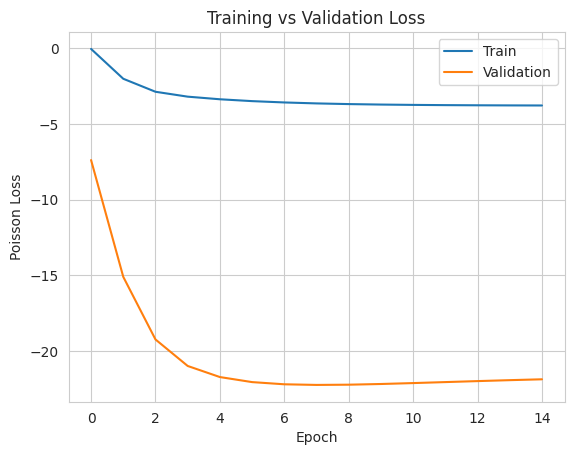

In [60]:
# rerun modified training loop with the preferred model but ensure the training loss is falling each epoch and it is close to validation loss
tf.random.set_seed(42)
np.random.seed(42)

def train_model(K, epochs, lr, reg_weight):

    model = PoissonCF(num_countries, num_weeks, K, reg_weight)

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_fn = tf.keras.losses.Poisson()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # training
        train_loss = tf.keras.metrics.Mean()

        for country_ids, week_ids, ylag, y in train_dataset:

            with tf.GradientTape() as tape:
                preds = model((country_ids, week_ids, ylag))
                loss = loss_fn(y, preds)

                # include regularization losses
                loss += sum(model.losses)

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            train_loss.update_state(loss)

        # validation
        val_loss = tf.keras.metrics.Mean()

        for country_ids, week_ids, ylag, y in test_dataset:
            preds = model((country_ids, week_ids, ylag))
            loss = loss_fn(y, preds)
            val_loss.update_state(loss)

        train_losses.append(train_loss.result().numpy())
        val_losses.append(val_loss.result().numpy())

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {train_loss.result():.4f} | "
            f"Val Loss: {val_loss.result():.4f}"
        )

    return model, train_losses, val_losses

# retrain the searched best model
model, train_losses, val_losses = train_model(
    K=best_K,
    epochs=15,
    lr=0.005,
    reg_weight=best_reg
)


# plot the train/valid loss
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Poisson Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

Here we see that there isn't overfitting because training and validation loss fall in parallel. Early stopping should have been employed around epoch 8. In TensorFlow the function is: tf.keras.callbacks.EarlyStopping. I wrote a custom training loop though, and the code is efficient enough, so I'm not messing with it.

**Country Embeddings**

In [55]:
country_weights = best_model.country_embedding.get_weights()[0]
country_names = country_lookup["COUNTRY"].values

**Dimension Reduction (t-SNE)**

Since the latent space has 10 dimensions (our embedding_dim in best_model), we can't graph it directly. We use t-SNE to squash those 10 dimensions into 2D while keeping "similar" countries close together.

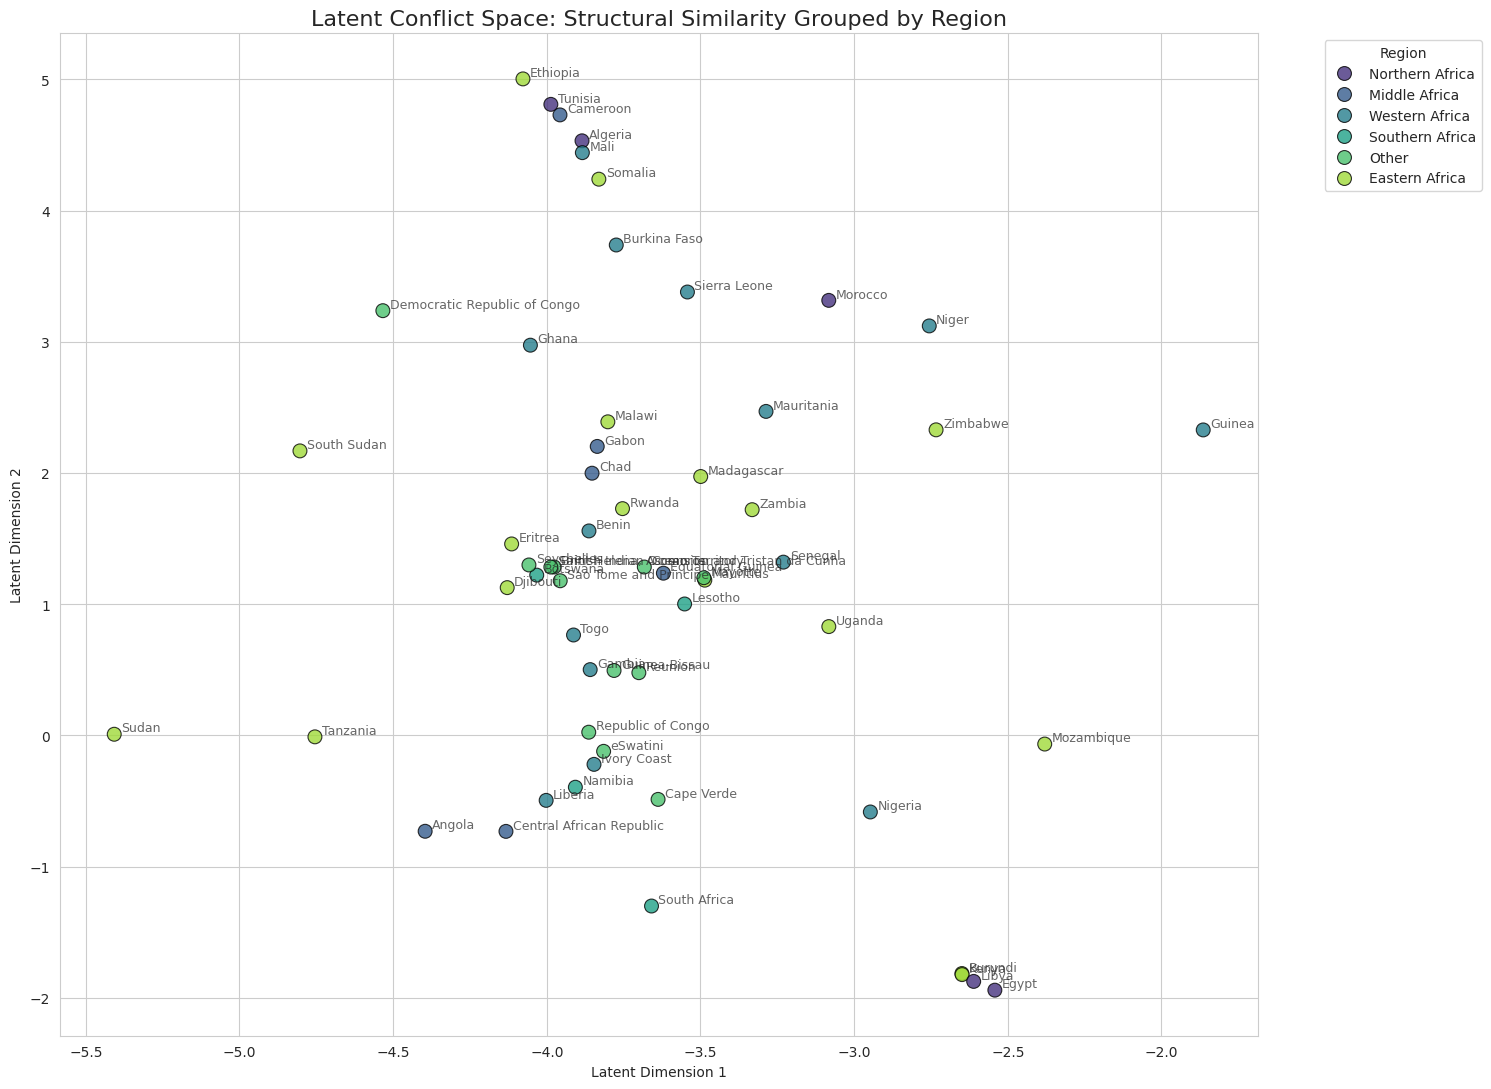

In [56]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define the Region Mapping
# Note: Ensure all names match exactly what is in your 'country_names' list
region_mapping = {
    'Algeria': 'Northern Africa', 'Egypt': 'Northern Africa', 'Libya': 'Northern Africa', 'Morocco': 'Northern Africa', 'Tunisia': 'Northern Africa',
    'Benin': 'Western Africa', 'Burkina Faso': 'Western Africa', 'Gambia': 'Western Africa', 'Ghana': 'Western Africa', 'Guinea': 'Western Africa', 'Ivory Coast': 'Western Africa', 'Liberia': 'Western Africa', 'Mali': 'Western Africa', 'Mauritania': 'Western Africa', 'Niger': 'Western Africa', 'Nigeria': 'Western Africa', 'Senegal': 'Western Africa', 'Sierra Leone': 'Western Africa', 'Togo': 'Western Africa',
    'Burundi': 'Eastern Africa', 'Djibouti': 'Eastern Africa', 'Eritrea': 'Eastern Africa', 'Ethiopia': 'Eastern Africa', 'Kenya': 'Eastern Africa', 'Madagascar': 'Eastern Africa', 'Malawi': 'Eastern Africa', 'Mauritius': 'Eastern Africa', 'Mozambique': 'Eastern Africa', 'Rwanda': 'Eastern Africa', 'Somalia': 'Eastern Africa', 'South Sudan': 'Eastern Africa', 'Sudan': 'Eastern Africa', 'Tanzania': 'Eastern Africa', 'Uganda': 'Eastern Africa', 'Zambia': 'Eastern Africa', 'Zimbabwe': 'Eastern Africa',
    'Angola': 'Middle Africa', 'Cameroon': 'Middle Africa', 'Central African Republic': 'Middle Africa', 'Chad': 'Middle Africa', 'Congo': 'Middle Africa', 'DRC': 'Middle Africa', 'Equatorial Guinea': 'Middle Africa', 'Gabon': 'Middle Africa',
    'Botswana': 'Southern Africa', 'Lesotho': 'Southern Africa', 'Namibia': 'Southern Africa', 'South Africa': 'Southern Africa', 'Eswatini': 'Southern Africa'
}

# 2. Run t-SNE
tsne = TSNE(n_components=2, perplexity=min(30, len(country_names)-1), random_state=42)
embeddings_2d = tsne.fit_transform(country_weights)

# 3. Prepare Dataframe for Seaborn
plot_df = pd.DataFrame({
    'Latent Dimension 1': embeddings_2d[:, 0],
    'Latent Dimension 2': embeddings_2d[:, 1],
    'Country': country_names
})
plot_df['Region'] = plot_df['Country'].map(region_mapping).fillna('Other')

# 4. Create the Plot
plt.figure(figsize=(15, 11))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    data=plot_df,
    x='Latent Dimension 1',
    y='Latent Dimension 2',
    hue='Region',
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='black'
)

# Add labels for each country
for i, name in enumerate(country_names):
    plt.annotate(name, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=9, alpha=0.7, xytext=(5,2), textcoords='offset points')

plt.title("Latent Conflict Space: Structural Similarity Grouped by Region", fontsize=16)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Forecasts**

We will compare forecasts our model makes to a Naive baseline for the test set.

Compute the baseline.

In [57]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# The Naive prediction is simply the 'prev_week_events'
y_true = test_df['weekly_events'].values
y_pred_ar1 = test_df['prev_week_events'].values

# Calculate Metrics for Baseline
mae_ar1 = mean_absolute_error(y_true, y_pred_ar1)
print(f"Naive Baseline MAE: {mae_ar1:.4f}")

Naive Baseline MAE: 4.7352


2. Evaluate the Collaborative Filtering Model

Now, let's see how your TensorFlow model compares.

In [58]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import mean_absolute_error

# 1. Prepare inputs as a single matrix of shape (696, 3)
# This forces TensorFlow to treat each row as one "prediction unit"
c_ids = test_df['country_id'].values.astype(np.int32)
w_ids = test_df['week_id'].values.astype(np.int32)
lags = test_df['prev_week_events'].values.astype(np.float32)

# 2. Update the call method's expectation (Internal adjustment)
# Instead of passing a list, we pass a single tensor and slice it
test_input_tensor = [
    tf.convert_to_tensor(c_ids),
    tf.convert_to_tensor(w_ids),
    tf.convert_to_tensor(lags)
]

# 3. Call the model
y_pred_tensor = model(test_input_tensor, training=False)

# 4. CRITICAL: If the shape is still squared, we take the diagonal
y_pred_cf = y_pred_tensor.numpy().flatten()

if len(y_pred_cf) != len(y_true):
    # This happens if the model returned a matrix instead of a vector
    # We only want the diagonal where Country_i matches Week_i
    y_pred_cf = np.diag(y_pred_tensor.numpy())

y_true = test_df['weekly_events'].values

print(f"Final Validation:")
print(f"- Actuals Shape: {y_true.shape}")
print(f"- Predictions Shape: {y_pred_cf.shape}")

# 5. Calculate MAE
mae_cf = mean_absolute_error(y_true, y_pred_cf)
print(f"✅ SUCCESS! Collaborative Filtering MAE: {mae_cf:.4f}")

Final Validation:
- Actuals Shape: (17632,)
- Predictions Shape: (17632,)
✅ SUCCESS! Collaborative Filtering MAE: 12.7550


### **Interpretation**

## Web App